In [55]:
import numpy as np
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt

data_path = '/mnt/jet1/zagorulia/data_one_channel'
val_path = '/mnt/jet1/zagorulia/val_one_channel'

In [56]:
os.listdir(f'{data_path}')[:5]

['J2213+3006_C_2020_09_11_pet_map.png',
 'J2350+3600_X_2016_01_10_pet_map.png',
 'J1939-1525_X_2016_07_06_pet_map.png',
 'J0209-0438_X_2017_08_05_pus_map.png',
 'J1923+4754_S_2018_07_05_pet_map.png']

(256, 256)


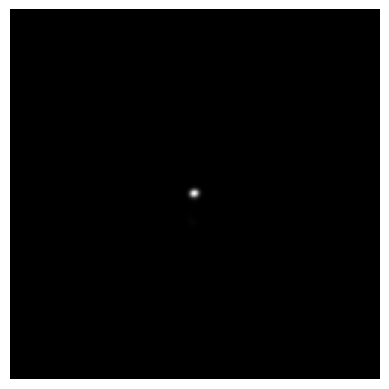

In [57]:
source =  'J0239-0234_X_2008_04_02_pus_map.png'
im = Image.open(f'{data_path}/{source}')
print(np.array(im).shape)
plt.imshow(im, cmap="gray")
plt.axis('off')
plt.show()

In [58]:
os.listdir(f'{val_path}/{2}')[:5]

['J0051-0650_S_2014_08_09_pus_map.png',
 'J1406-0707_C_2019_01_16_pet_map.png',
 'J0203+7232_X_2017_03_27_pet_map.png',
 'J2348-1631_U_1998_03_07_moj_map.png',
 'J0830-0242_C_2016_05_27_pet_map.png']

In [59]:
def map_noise(data, k=0.1) -> float:
    b1, b2 = int(k * data.shape[0]), int(k * data.shape[1])
    b3, b4 = int((1-k) * data.shape[0]), int((1-k) * data.shape[1])
    upper_left = np.std(data[:b1, :b2])
    upper_right = np.std(data[b3:, :b2])
    down_left = np.std(data[:b1, b4:])
    down_right = np.std(data[b3:, b4:])
    noise = np.median([upper_left, upper_right, down_left, down_right])
    return noise

(512, 512) 0.0


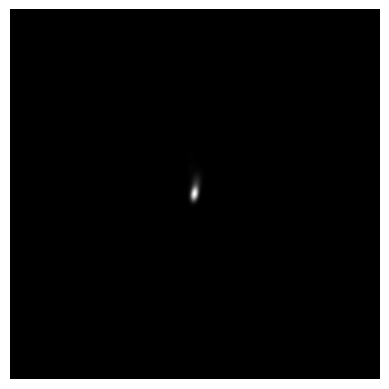

In [60]:
from PIL import Image
import matplotlib.pyplot as plt

source =  'J0237+2848_S_2003_07_09_nic_map.png'
im = Image.open(f'{val_path}/{2}/{source}')
print(np.array(im).shape, map_noise(np.array(im)))
plt.imshow(im, cmap="gray")
plt.axis('off')
plt.show()

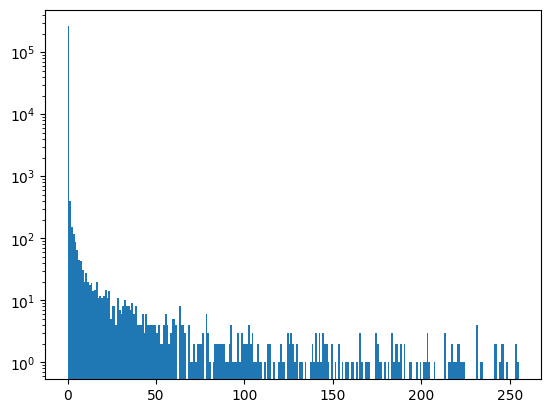

In [61]:
plt.hist(np.array(im).ravel(), bins=range(0, 256))
plt.yscale('log')
plt.show()

In [62]:
print(np.array(im).ravel().sum())
print(map_noise(np.array(im)))
print(np.array(im).std())

45817
0.0
4.552483921128925


0.0


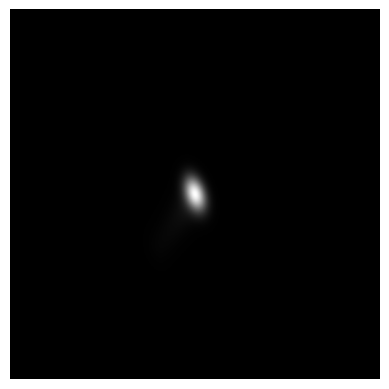

In [63]:
syntetic_path = '../../synt_one_channel'
source = '1.png'

im = np.array(Image.open(f'{syntetic_path}/{2}/{source}'))
im = im.clip(min=0)
im = (im / im.max() * 255).astype(np.uint8)
print(map_noise(im))
im = Image.fromarray(im)
plt.imshow(im, cmap="gray")
plt.axis('off')
plt.show()

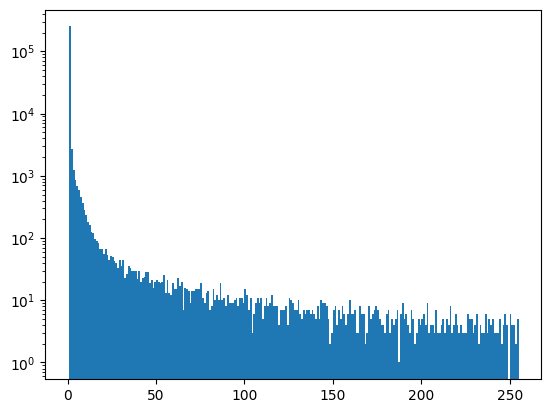

In [64]:
plt.hist(np.array(im).ravel(), bins=range(0, 256))
plt.yscale('log')
plt.show()

In [65]:
print(np.array(im).ravel().sum())
print(map_noise(np.array(im)))
print(np.array(im).std())

521362
0.0
10.672450009059087


In [66]:
# import torchvision.transforms.functional as F
# import torch
# import torchvision.transforms.v2 as v2

# # contast = v2.RandomAutocontrast(p=0.5)
# # im = contast(im)
# norm = v2.Normalize(mean=(0,), std=(1,))
# im = norm((F.pil_to_tensor(im).to(float)))
# plt.imshow(im, cmap="gray")
# plt.axis('off')
# plt.show()